### Load and Clip the Arctic DEM

Notebook contents 
* Take a look at the Arctic DEM downloaded in `hdd/snow_hydrology/DEMs/`
* Develop processing workflow 

created by Cassie Lumbrazo\
last updated: April 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [2]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box, mapping
from pyproj import Transformer, CRS
import os

In [3]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

### Open the ArcticDEM, which is already in UTM 

In [4]:
# File paths 
filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM/'
# filename =  '40_05_2_2_2m_v4.1_dem.tif' # this file is in EPSG:3413 
filename =  '40_05_2_2_2m_v4.1_dem_UTM.tif'# now, this file should be in UTM coordinates (EPSG:32608)
raster_path = os.path.join(filepath, filename)

One way to open the raster which I was doing before, 

In [5]:
# open the DEM with rioxarray
dem = rioxarray.open_rasterio(raster_path, masked=True)
# dem = dem.rio.write_crs("EPSG:32608")  # Set the CRS to UTM Zone 8N

dem.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]')

In [6]:
# check the dem units 
dem

<xarray.DataArray (band: 1, y: 25127, x: 25127)> Size: 3GB
[631366129 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 201kB 4.999e+05 4.999e+05 ... 5.478e+05 5.478e+05
  * y            (y) float64 201kB 6.482e+06 6.482e+06 ... 6.434e+06 6.434e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1681.8046875
    STATISTICS_MEAN:           294.3732441994
    STATISTICS_MINIMUM:        -4.1796875
    STATISTICS_STDDEV:         359.67656729573
    STATISTICS_VALID_PERCENT:  98.75
    scale_factor:              1.0
    add_offset:                0.0

In [7]:
# check the dem for missing data
print("total pixels:", dem.sum().values)
print("# that are nan:", dem.isnull().sum().values)

total pixels: 186105050000.0
# that are nan: 1567773


Or just using rasterio.open directly, 

In [8]:
with rasterio.open(raster_path) as src:
    print("Original CRS:", src.crs)

src

Original CRS: EPSG:32608


<closed DatasetReader name='/hdd/snow_hydrology/DEMs/ArcticDEM/40_05_2_2_2m_v4.1_dem_UTM.tif' mode='r'>

 The bounding box is currently in lat/lon (EPSG:4326). Thus, to clip using UTM coordinates, then we need to provide the bounding box in the correct UTM zone

 `(e.g., UTM Zone 8N is common for SE Alaska → EPSG:32608).`

In [9]:
# My previous bounding box 
# Define bounding box in lon/lat (EPSG:4326) which was the easiest to get the coords for, 
# This bounding box is for the general Juneau region
xmin, xmax = -134.964, -133.893
ymin, ymax = 58.077, 58.603

utm_crs = CRS.from_epsg(32608)  # UTM Zone 8N

# Now, transform bbox from lon/lat to UTM
transformer = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)

# And create UTM bbox geometry
utm_bbox = box(xmin_utm, ymin_utm, xmax_utm, ymax_utm)
geojson_geom = [mapping(utm_bbox)]

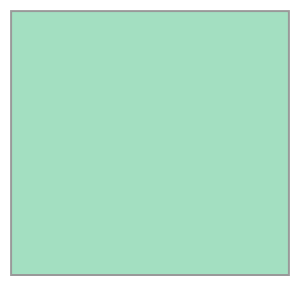

In [10]:
utm_bbox

In [11]:
geojson_geom

[{'type': 'Polygon',
  'coordinates': (((564328.4312519523, 6437283.425855768),
    (564328.4312519523, 6496377.68123901),
    (502123.3616267206, 6496377.68123901),
    (502123.3616267206, 6437283.425855768),
    (564328.4312519523, 6437283.425855768)),)}]

Now, we have the dem in UTM, and we have the bounding box in UTM, so we can now clip the raster without introducing any errors with reprojection, 

In [12]:
# provide the polygon in UTM
clip_polygon = geojson_geom[0]  # Extract the polygon from the GeoJSON geometry
# clip_polygon = geojson_geom  # If you want to use the entire GeoJSON geometry

# clip the raster using the polygon
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, [clip_polygon], crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

In [13]:
clip_raster_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/40_05_2_2_2m_v4.1_dem_UTM_clip.tif'

# and save the out_image and out_meta to a new file
with rasterio.open(clip_raster_path, "w", **out_meta) as dest:
    dest.write(out_image)

In [14]:
# Now open the new clipped raster
clipped_dem = rioxarray.open_rasterio(clip_raster_path, masked=True)
clipped_dem.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]')

In [15]:
# clipped_dem.plot()

## Clean up that code from above for easy future use, 

In [16]:
# coords for the Juneau DEM, which we used above (lets rerun and resave for future use)
xmin, xmax = -134.964, -133.893
ymin, ymax = 58.077, 58.603

# Now, transform bbox from lon/lat to UTM
utm_crs = CRS.from_epsg(32608)  # UTM Zone 8N
transformer = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)

# And create UTM bbox geometry
utm_bbox = box(xmin_utm, ymin_utm, xmax_utm, ymax_utm)
geojson_geom = [mapping(utm_bbox)]

# provide the polygon in UTM
clip_polygon = geojson_geom[0]  # Extract the polygon from the GeoJSON geometry

# Imput the path to the raster you want to clip
raster_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/40_05_2_2_2m_v4.1_dem_UTM.tif'

# Clip the raster using the polygon
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, [clip_polygon], crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })
    
# and save the out_image and out_meta to a new file
clip_raster_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_juneau.tif'
with rasterio.open(clip_raster_path, "w", **out_meta) as dest:
    dest.write(out_image)

In [17]:
with rasterio.open(clip_raster_path) as src:
    print("Resolution:", src.res)

Resolution: (1.9073778775780803, 1.9073778775780803)


Editing the code because we want to make sure the raster is clipped with square cells, not rectangular 

In [18]:
# Define clipping bounds in lon/lat (WGS84)
xmin, xmax = -134.964, -133.893
ymin, ymax = 58.077, 58.603

# Transform to UTM Zone 8N
utm_crs = CRS.from_epsg(32608)
transformer = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)

# Create a UTM bounding box polygon
utm_bbox = box(xmin_utm, ymin_utm, xmax_utm, ymax_utm)
clip_polygon = [mapping(utm_bbox)]

# Input and output paths
raster_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/40_05_2_2_2m_v4.1_dem_UTM.tif"
clip_raster_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_square_UTM_clip_juneau.tif"

# Target resolution
target_res = 2  # meters (square)

with rasterio.open(raster_path) as src:
    # First clip to bounding box
    clipped, clipped_transform = mask(src, clip_polygon, crop=True)
    
    # Calculate the transform for square pixels
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, src.crs,  # No reprojection, just resampling
        src.width, src.height,
        *utm_bbox.bounds,
        resolution=(target_res, target_res)
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "height": dst_height,
        "width": dst_width,
        "transform": dst_transform,
        "dtype": src.dtypes[0],
        "crs": src.crs
    })

    with rasterio.open(clip_raster_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=clipped[i-1],
                destination=rasterio.band(dst, i),
                src_transform=clipped_transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=src.crs,
                resampling=Resampling.bilinear
            )

In [19]:
with rasterio.open(clip_raster_path) as src:
    print("Resolution:", src.res)

Resolution: (2.0, 2.0)


So, that worked. We want to use this code to ensure the boxes are exactly square

#### And, do the same for directly over Powder Patch, which is an even smaller area than above 

In [20]:
# if we want to clip this to an even smaller area just for testing around Powder Patch...

# using this website to get the coordinates in CSV: https://boundingbox.klokantech.com/
xmin, ymin, xmax, ymax = -134.594876,58.238519,-134.445151,58.308517

# Transform to UTM Zone 8N
utm_crs = CRS.from_epsg(32608)
transformer = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)

# Create a UTM bounding box polygon
utm_bbox = box(xmin_utm, ymin_utm, xmax_utm, ymax_utm)
clip_polygon = [mapping(utm_bbox)]

# Input and output paths
raster_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/40_05_2_2_2m_v4.1_dem_UTM.tif"
clip_raster_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif'

# Target resolution
target_res = 2  # meters (square)

with rasterio.open(raster_path) as src:
    # First clip to bounding box
    clipped, clipped_transform = mask(src, clip_polygon, crop=True)
    
    # Calculate the transform for square pixels
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, src.crs,  # No reprojection, just resampling
        src.width, src.height,
        *utm_bbox.bounds,
        resolution=(target_res, target_res)
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "height": dst_height,
        "width": dst_width,
        "transform": dst_transform,
        "dtype": src.dtypes[0],
        "crs": src.crs
    })

    with rasterio.open(clip_raster_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=clipped[i-1],
                destination=rasterio.band(dst, i),
                src_transform=clipped_transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=src.crs,
                resampling=Resampling.bilinear
            )

In [21]:
with rasterio.open(clip_raster_path) as src:
    print("Resolution:", src.res)

Resolution: (2.0, 2.0)


In [22]:
# Just curious, open the new clipped raster
clipped_dem = rioxarray.open_rasterio(clip_raster_path, masked=True)
clipped_dem.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]')

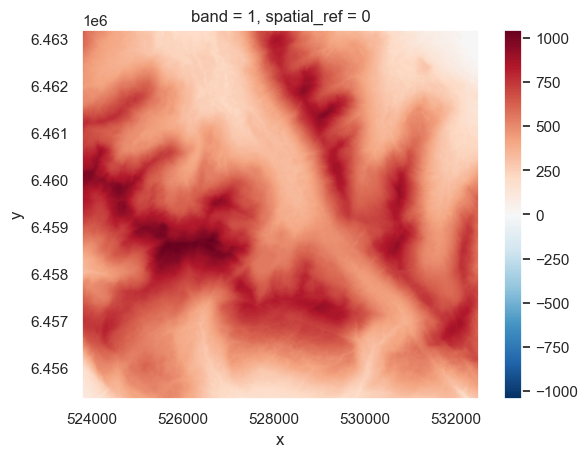

In [23]:
clipped_dem.plot()

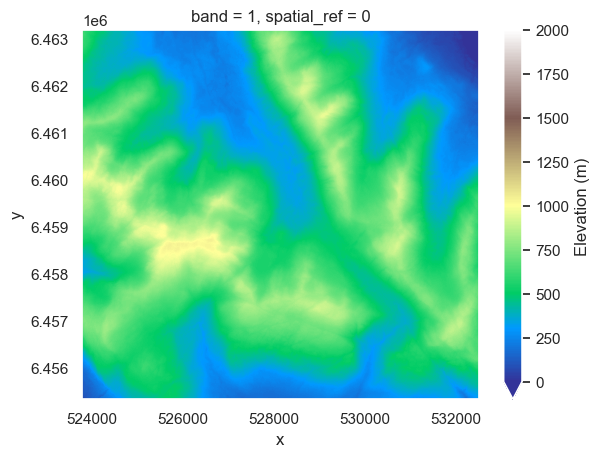

In [24]:
clipped_dem.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

In [25]:
# check the clipped_dem for missing data
print("total pixels:", clipped_dem.sum().values)
print("# that are nan:", clipped_dem.isnull().sum().values)

total pixels: 9023617000.0
# that are nan: 3928


### Double Checking Units

We know that the Powder Patch Met Station is at 2198ft which is 670m, and the highest point over Douglas Island should be no more than 2,750ft which is 838m. 

So given the values we see in the above figure, with the highest ridge of Eagle Crest < 1000, then this DEM is in meters. 